# Perovskite Energy Yield with Degradation
Predicts real-world operational lifetime ($T_{80}$, $T_{90,Agg}$) and hourly energy yield of a
single-junction perovskite solar cell using the combined **Arrhenius + power-law** degradation model of
Orooji et al. (2026), parameterised from the accelerated aging data of Zhao et al. (2022).

**Models covered:**
1. **Device-level CE degradation factor** — `perovskite_degradation_factor()` (D046, CsPbI₃)
2. **Energy yield with pvlib single-diode model** — `degraded_power_ratio()` computes hourly $P_{mp}$,
   aggregated power ratio $PR_{Agg}(t)$, and $T_{90,Agg}$.
3. **Multi-location comparison** — Assess multiple locations with T₈₀ and T₉₀ thresholds.

**Key equations:**

$$k(T_i, I_i) = k_0 \cdot \exp\!\left(\frac{-E_a}{k_B T_i}\right) \cdot \left(\frac{I_i}{I_{ref}}\right)^{\!\gamma}$$

$$DF(i) = A_1 e^{-k_{fast} \cdot 1\text{h}} + A_2 e^{-k_{slow} \cdot 1\text{h}} + B
\qquad
DF_{total}(t) = \prod_{i=1}^{t} DF(i)$$

$$PR_{Agg}(t) = \frac{\sum_{i=1}^{t} P_{deg}(i)}{\sum_{i=1}^{t} P_{ref}(i)}$$

**References:**
- Orooji et al. (2026) *EES Solar*. doi: 10.1039/d6el00021e
- Zhao et al. (2022) *Science* 377, 307–310. doi: 10.1126/science.abn5679

## 1. Imports and data

In [1]:
import os
import json
import tempfile
import pvlib
import numpy as np
import pandas as pd
import pvdeg
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import plotly.express as px
import plotly.graph_objects as go

# Redirect all Scenario job folders to the system temp directory.
# Keeps the repo working directory free of pvd_job_* clutter.
pvdeg.config.SCENARIO_OUTPUT_PATH = tempfile.gettempdir()

# Lifetime threshold e.g. 0.90 for T90
T_THRESHOLD = 0.90
T_LABEL = f"T{int(T_THRESHOLD * 100)}"  # e.g. "T90" or "T80"

# Note: Orooji et al. (2026) model the energy yield of a Perovskite/Si tandem device
# using LTspice and EYCalc, including only degradation of the top cell. For simplicity,
# this example models the degradation and subsequent energy yield of a single-junction
# perovskite top cell, using the same published perovskite top cell parameters.
TOP_CELL_PARAM = {
    "I_sc_ref": 0.02076,  # A   (Jsc 20.76 mA/cm^2 for 1 cm^2; tandem current-matched)
    "I_0_ref": 2.6e-18,  # A   (J0 = 2.6e-18 A/cm^2)
    "R_s": 1.4,  # Ohm (1.4 Ohm.cm^2)
    "R_sh": 1300.0,  # Ohm (1300 Ohm.cm^2)
    "n_diode": 1.3,  # ideality factor
}

In [2]:
# Use some local data shipped with pvdeg first to avoid API calls
LOCATIONS = {
    "Golden, CO": ("psm4_golden.csv", "meta_golden.json"),
    "Miami, FL": ("psm4_miami.csv", "meta_miami.json"),
    "New York, NY": ("psm4_nyc.csv", "meta_nyc.json"),
}

all_weather, all_meta = {}, {}
for loc, (wf, mf) in LOCATIONS.items():
    df = pd.read_csv(
        os.path.join(pvdeg.DATA_DIR, wf),
        index_col=0,
        parse_dates=True,
    )
    df.index = df.index.map(lambda ts: ts.replace(year=2020))
    df = df.sort_index()
    with open(os.path.join(pvdeg.DATA_DIR, mf)) as _f:
        mt = json.load(_f)
    all_weather[loc], all_meta[loc] = df, mt
    print(f"  {loc}: {len(df)} rows  ({mt['latitude']:.2f}°N, {mt['longitude']:.2f}°E)")

# Single-location aliases used by the EY demonstration cells below
weather_df = all_weather["Golden, CO"]
meta = all_meta["Golden, CO"]
display_year = 2020

  Golden, CO: 8760 rows  (39.73°N, -105.18°E)


  Miami, FL: 8760 rows  (25.77°N, -80.18°E)


  New York, NY: 8760 rows  (40.65°N, -73.98°E)


---
## 2. Zhao / Orooji degradation parameters (D046)

The model is parameterised from the **uncapped CsPbI₃** device in Zhao et al. (2022),
which was aged at 35–110 °C under ~1200 W m⁻² continuous illumination.
Activation energies come directly from the Arrhenius plot (Fig. 3C of the paper):

| Parameter | Value | Meaning |
|-----------|-------|---------|
| $E_{a,fast}$ | 0.248 eV | Activation energy of the fast degradation process |
| $E_{a,slow}$ | 0.243 eV | Activation energy of the slow degradation process |
| $A_1$ | 0.25 | Amplitude of the fast exponential |
| $A_2$ | 0.70 | Amplitude of the slow exponential |
| $B$ | 0.05 | Residual stable fraction (long-term plateau) |
| $\gamma$ | 1.0 | Light-intensity exponent |
| $I_{ref}$ | 1200 W m⁻² | Reference irradiance of the aging experiment |

These are stored in `DegradationDatabase.json` entry **D046** and loaded below.

In [3]:
d046 = pvdeg.utilities.get_kinetics("D046")

print("D046 — Zhao et al. 2022 (uncapped CsPbI₃, doi: 10.1126/science.abn5679)")
skip = {
    "DataEntryPerson",
    "DateEntered",
    "doi",
    "SourceTitle",
    "Authors",
    "Reference",
    "Material",
    "EquationType",
    "Comments",
}
for k, v in d046.items():
    if k not in skip:
        print(f"  {k}: {v}")

D046 — Zhao et al. 2022 (uncapped CsPbI₃, doi: 10.1126/science.abn5679)
  Ea_fast: 0.248
  Ea_slow: 0.243
  k0_fast: 0.56
  k0_slow: 0.48
  A1: 0.25
  A2: 0.7
  B: 0.05
  gamma: 1.0
  I_ref: 1200.0


---
## 3. Scenario pipeline — chained, converging jobs

Four jobs run inside a single Scenario pipeline. The graph **fans out** from `poa` to the
module-temperature and CE-factor jobs, then **converges**: the energy-yield job depends on
three upstream outputs at once (`poa`, `temp_mod`, `ce_factor`).

`degraded_power_ratio()` returns a `dict`; the Scenario stores it under `sc.results["ey"]`,
from which we read `PR_Agg`, `power_degraded`, and `power_reference`.

| Step | Function | Output name | Depends on |
|------|----------|-------------|------------|
| 1 | `spectral.poa_irradiance` | `"poa"` | — |
| 2 | `temperature.module` | `"temp_mod"` | `poa` ← `"poa"` |
| 3 | `degradation.perovskite_degradation_factor` (D046) | `"ce_factor"` | `poa` ← `"poa"` |
| 4 | `degradation.degraded_power_ratio` | `"ey"` | `poa` ← `"poa"`, `temp_cell` ← `"temp_mod"`, `ce_factor` ← `"ce_factor"` |

Directed Acyclic Graphs (DAG) mapping out dependencies:
```
        ┌──> temp_mod ──┐
poa ────┤               ├──> ey   (degraded_power_ratio)
        └──> ce_factor ─┘
```


In [4]:
scenarios = {}
for loc in LOCATIONS:
    sc = pvdeg.Scenario(
        name=f"ey-{loc.split(',')[0].lower().replace(' ', '-')}",
        weather_data=all_weather[loc],
        meta_data=all_meta[loc],
    )
    sc.addJob(
        func=(
            pvdeg.spectral.poa_irradiance,
            {
                "surface_tilt": abs(all_meta[loc]["latitude"]),
                "surface_azimuth": 180.0,
            },
        ),
        name="poa",
    )
    sc.addJob(
        func=pvdeg.temperature.module,
        name="temp_mod",
        depends_on={"poa": "poa"},
    )
    sc.addJob(
        func=(pvdeg.degradation.perovskite_degradation_factor, {"parameters": d046}),
        name="ce_factor",
        depends_on={"poa": "poa"},
    )
    # Converging job: energy yield consumes three upstream outputs at once.
    # weather_df and meta are injected by the Scenario; TOP_CELL_PARAM supplies
    # the diode parameters. degraded_power_ratio returns a dict
    sc.addJob(
        func=(pvdeg.degradation.degraded_power_ratio, TOP_CELL_PARAM),
        name="ey",
        depends_on={"poa": "poa", "temp_cell": "temp_mod", "ce_factor": "ce_factor"},
    )
    sc.run()
    scenarios[loc] = sc
    print(f"  {loc}: CE@year-end = {sc.results['ce_factor'].iloc[-1]:.4f}")

# Golden, CO aliases for the EY cells below
s = scenarios["Golden, CO"]
ce_factor = s.results["ce_factor"]
poa_df = s.results["poa"]
temp_mod = s.results["temp_mod"]
ey = s.results["ey"]  # dict: PR_Agg, T90_Agg_hours, power_degraded, power_reference

The array surface_tilt angle was not provided, therefore the latitude of  39.7 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  Golden, CO: CE@year-end = 0.9052


The array surface_tilt angle was not provided, therefore the latitude of  25.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.


  Miami, FL: CE@year-end = 0.8799
The array surface_tilt angle was not provided, therefore the latitude of  40.6 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.


  New York, NY: CE@year-end = 0.9220


---
## 4. Energy yield and lifetime over multiple years

A single meteorological year rarely crosses `T_THRESHOLD`, so we **tile** the TMY across
`N_YEARS` and run the full converging pipeline on the tiled series. The running product
in `perovskite_degradation_factor()` accumulates continuously, so the whole multi-year
series is passed as one input.

`ey_pipeline()` builds the same four-job DAG as Section 3 and returns the CE factor
($DF_{total}$) plus the complete `degraded_power_ratio` dict (`PR_Agg`, `power_degraded`,
`power_reference`), from which every visual below is drawn:

- **CE factor** $DF_{total}(t)$ — device-level degradation, all locations, with the $T_{90}$ crossing;
- **Aggregated power ratio** $PR_{Agg}(t)$ — cumulative energy-yield metric, with the $T_{90,Agg}$ crossing;
- **Hourly $P_{mp}$** — degraded vs reference cell (first year, Golden).

The photocurrent is scaled by the CE factor inside `degraded_power_ratio()`:

$$I_L^{deg}(t) = I_{sc,ref} \cdot \frac{G(t)}{G_{ref}} \cdot [1 + \alpha_{ISC}(T_{cell}(t) - T_{ref})] \cdot CE_{factor}(t)$$

Diode parameters are defined in `TOP_CELL_PARAM`. The original reference models a tandem
architecture with degradation in the top cell only; for simplicity we model that same
top cell but as a single-junction device with the degradation calculated the same way.


In [5]:
N_YEARS = 3  # increase if no location reaches T_THRESHOLD within the window


def make_multiyear(df, n_years, start_year=2020):
    """Tile a 1-year weather DataFrame across n_years by shifting the year index."""
    frames = []
    for y in range(n_years):
        yr = start_year + y
        f = df.copy()
        f.index = f.index.map(lambda ts, _yr=yr: ts.replace(year=_yr))
        frames.append(f)
    return pd.concat(frames).sort_index()


def ey_pipeline(wdf, mt, n_years=N_YEARS):
    """Full converging pipeline (POA -> temp + CE -> energy yield) on tiled weather.

    Builds the same four jobs as Section 3 and reads the results straight from the
    Scenario (degraded_power_ratio's dict lands in sc.results["ey"]).
    Returns (CE_series, ey_dict), where ey_dict holds PR_Agg, power_degraded,
    power_reference and T90_Agg_hours.
    Job folders go to pvdeg.config.SCENARIO_OUTPUT_PATH (set in the imports cell).
    """
    wdf_ny = make_multiyear(wdf, n_years)
    tilt = abs(mt["latitude"])
    sc = pvdeg.Scenario(name="ey-multiyear", weather_data=wdf_ny, meta_data=mt)
    sc.addJob(
        func=(
            pvdeg.spectral.poa_irradiance,
            {"surface_tilt": tilt, "surface_azimuth": 180.0},
        ),
        name="poa",
    )
    sc.addJob(func=pvdeg.temperature.module, name="temp_mod", depends_on={"poa": "poa"})
    sc.addJob(
        func=(pvdeg.degradation.perovskite_degradation_factor, {"parameters": d046}),
        name="ce_factor",
        depends_on={"poa": "poa"},
    )
    sc.addJob(
        func=(pvdeg.degradation.degraded_power_ratio, TOP_CELL_PARAM),
        name="ey",
        depends_on={"poa": "poa", "temp_cell": "temp_mod", "ce_factor": "ce_factor"},
    )
    sc.run()
    return sc.results["ce_factor"], sc.results["ey"]

In [6]:
_colors = {
    "Golden, CO": "steelblue",
    "Miami, FL": "crimson",
    "New York, NY": "seagreen",
}

# Run the full converging pipeline on N-year tiled weather for every local location.
# ey_pipeline returns (CE_series, ey_dict); we keep CE, PR_Agg, and the full dict
# (the dict carries power_degraded / power_reference for the hourly panel).
print(
    f"Running {N_YEARS}-year projection for all locations  (threshold = {T_LABEL})..."
)
ce_multiyear, pr_multiyear, ey_local = {}, {}, {}
for loc in LOCATIONS:
    ce, ey_d = ey_pipeline(all_weather[loc], all_meta[loc])
    ce_multiyear[loc] = ce
    pr_multiyear[loc] = ey_d["PR_Agg"]
    ey_local[loc] = ey_d

    pr = pr_multiyear[loc]
    t_idx = pr[pr <= T_THRESHOLD].index
    if len(t_idx):
        t_months = (t_idx[0] - pr.index[0]).days / 30.44
        print(f"  {loc}: {T_LABEL},Agg at {t_months:.1f} months")
    else:
        print(
            f"  {loc}: {T_LABEL},Agg not reached in {N_YEARS} years "
            f"(PR_Agg end = {pr.iloc[-1]:.3f})"
        )

Running 3-year projection for all locations  (threshold = T90)...


The array surface_tilt angle was not provided, therefore the latitude of  39.7 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.


  Golden, CO: T90,Agg at 23.9 months


The array surface_tilt angle was not provided, therefore the latitude of  25.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.


  Miami, FL: T90,Agg at 18.2 months


The array surface_tilt angle was not provided, therefore the latitude of  40.6 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.


  New York, NY: T90,Agg at 29.3 months


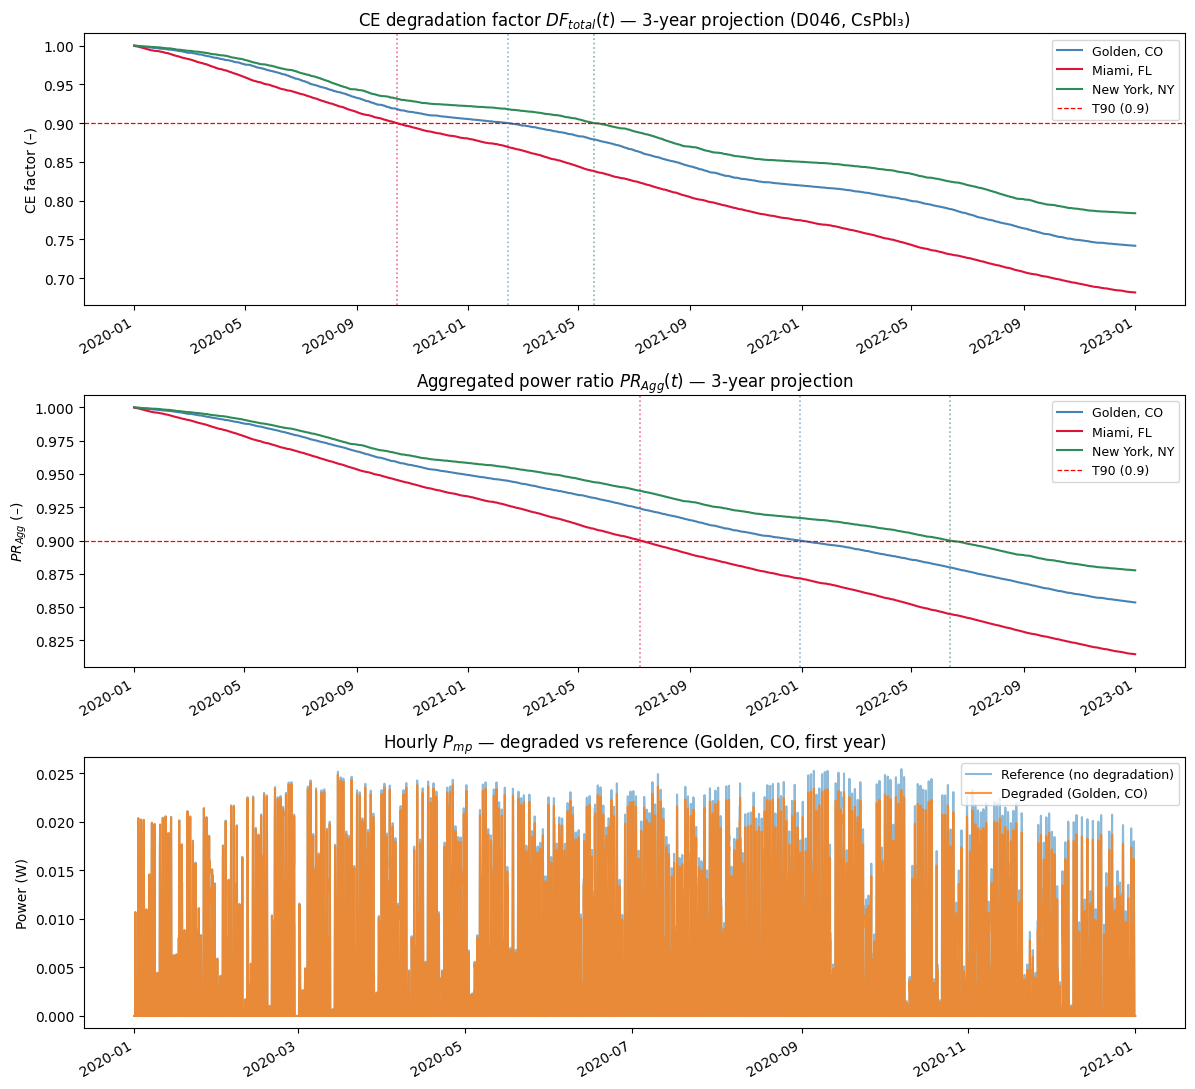

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11))

# Panel 1: CE degradation factor DF_total(t) — all locations + T90 crossings
for loc, ce in ce_multiyear.items():
    ce.plot(ax=axes[0], label=loc, color=_colors[loc])
    t_idx = ce[ce <= T_THRESHOLD].index
    if len(t_idx):
        axes[0].axvline(t_idx[0], color=_colors[loc], ls=":", alpha=0.6, lw=1.2)
axes[0].axhline(
    T_THRESHOLD, color="red", ls="--", lw=0.9, label=f"{T_LABEL} ({T_THRESHOLD})"
)
axes[0].set_ylabel("CE factor (–)")
axes[0].set_title(
    f"CE degradation factor $DF_{{total}}(t)$ — {N_YEARS}-year projection (D046, CsPbI₃)"
)
axes[0].legend(fontsize=9, loc="upper right")

# Panel 2: Aggregated power ratio PR_Agg(t) — all locations + T90,Agg crossings
for loc, pr in pr_multiyear.items():
    pr.plot(ax=axes[1], label=loc, color=_colors[loc])
    t_idx = pr[pr <= T_THRESHOLD].index
    if len(t_idx):
        axes[1].axvline(t_idx[0], color=_colors[loc], ls=":", alpha=0.6, lw=1.2)
axes[1].axhline(
    T_THRESHOLD, color="red", ls="--", lw=0.9, label=f"{T_LABEL} ({T_THRESHOLD})"
)
axes[1].set_ylabel("$PR_{Agg}$ (–)")
axes[1].set_title(f"Aggregated power ratio $PR_{{Agg}}(t)$ — {N_YEARS}-year projection")
axes[1].legend(fontsize=9, loc="upper right")

# Panel 3: Hourly power — degraded vs reference (Golden, first year for readability)
_gold = ey_local["Golden, CO"]
_p_ref, _p_deg = _gold["power_reference"], _gold["power_degraded"]
_first_year = _p_ref.index < _p_ref.index[0] + pd.DateOffset(years=1)
_p_ref[_first_year].plot(ax=axes[2], label="Reference (no degradation)", alpha=0.5)
_p_deg[_first_year].plot(ax=axes[2], label="Degraded (Golden, CO)", alpha=0.8)
axes[2].set_ylabel("Power (W)")
axes[2].set_title("Hourly $P_{mp}$ — degraded vs reference (Golden, CO, first year)")
axes[2].legend(fontsize=9)

fig.tight_layout()

---
## 5. Lifetime map — US state choropleth via NSRDB PSM4

Each state is coloured by how many months it takes until the **cumulative energy yield**
(`PR_Agg`) falls below `T_THRESHOLD`using a 3-year tiled PSM4 TMY. Colour scale: green = long lifetime (good), red = short lifetime (bad).

This is the energy-yield answer to "when have I lost `(1 − T_THRESHOLD) × 100 %` of my
investment?".


**Note on DF_total**
$DF_{total}$ is the *instantaneous* CE at a given hour, $PR_{Agg}$ is the averaged energy
yield over the whole operating period.


In [ ]:
# NBVAL_IGNORE_OUTPUT
# Fetch lifetime data for all 50 US states via NSRDB PSM4 API
# Get a free key at https://developer.nrel.gov/signup/

API_KEY = "7SNYG6jZv3arhg1hKj1zWI0Y9gO1mXUBvhsK2b1J"
EMAIL = "rajiv.daxini@nlr.gov"

# abbr: (api_lat, api_lon, label, centre_lat, centre_lon)
# (UN)COMMENT whichever states you want
STATES = {
    # "AL": (32.36, -86.30, "Montgomery, AL", 32.8, -86.8),
    # "AK": (61.22, -149.90, "Anchorage, AK", 64.2, -153.0),
    "AZ": (33.45, -112.07, "Phoenix, AZ", 34.3, -111.1),
    # "AR": (34.74, -92.33, "Little Rock, AR", 34.8, -92.2),
    # "CA": (34.05, -118.24, "Los Angeles, CA", 37.2, -119.5),
    # "CO": (39.73, -104.98, "Denver, CO", 39.0, -105.5),
    # "CT": (41.76, -72.68, "Hartford, CT", 41.6, -72.7),
    # "DE": (39.16, -75.52, "Dover, DE", 39.0, -75.5),
    "FL": (25.77, -80.19, "Miami, FL", 27.8, -81.6),
    # "GA": (33.75, -84.39, "Atlanta, GA", 32.7, -83.4),
    "HI": (21.31, -157.86, "Honolulu, HI", 20.5, -157.3),
    # "ID": (43.61, -116.20, "Boise, ID", 44.4, -114.6),
    # "IL": (41.88, -87.63, "Chicago, IL", 40.0, -89.2),
    # "IN": (39.77, -86.16, "Indianapolis, IN", 40.3, -86.1),
    # "IA": (41.59, -93.62, "Des Moines, IA", 42.0, -93.5),
    # "KS": (39.05, -95.69, "Topeka, KS", 38.5, -98.4),
    # "KY": (38.25, -85.76, "Louisville, KY", 37.5, -85.3),
    # "LA": (29.95, -90.07, "New Orleans, LA", 31.1, -91.8),
    "ME": (43.66, -70.26, "Portland, ME", 45.4, -69.2),
    # "MD": (38.97, -76.49, "Annapolis, MD", 39.0, -76.7),
    # "MA": (42.36, -71.06, "Boston, MA", 42.3, -71.8),
    # "MI": (42.73, -84.56, "Lansing, MI", 44.3, -85.4),
    # "MN": (44.94, -93.09, "Minneapolis, MN", 46.4, -93.1),
    # "MS": (32.30, -90.18, "Jackson, MS", 32.7, -89.7),
    # "MO": (38.57, -92.17, "Jefferson City, MO", 38.4, -92.5),
    # "MT": (46.60, -112.02, "Helena, MT", 47.0, -110.4),
    # "NE": (40.81, -96.68, "Lincoln, NE", 41.5, -99.9),
    # "NV": (36.17, -115.14, "Las Vegas, NV", 39.3, -116.6),
    # "NH": (43.21, -71.54, "Concord, NH", 43.7, -71.6),
    # "NJ": (40.22, -74.76, "Trenton, NJ", 40.1, -74.5),
    # "NM": (35.67, -105.96, "Santa Fe, NM", 34.4, -106.1),
    # "NY": (40.71, -74.01, "New York, NY", 42.9, -75.6),
    # "NC": (35.78, -78.64, "Raleigh, NC", 35.5, -79.4),
    # "ND": (46.81, -100.78, "Bismarck, ND", 47.5, -100.5),
    # "OH": (39.96, -82.99, "Columbus, OH", 40.4, -82.8),
    # "OK": (35.47, -97.52, "Oklahoma City, OK", 35.6, -97.5),
    # "OR": (44.94, -123.03, "Salem, OR", 44.1, -120.5),
    # "PA": (40.27, -76.88, "Harrisburg, PA", 40.9, -77.8),
    # "RI": (41.82, -71.42, "Providence, RI", 41.7, -71.5),
    # "SC": (34.00, -81.03, "Columbia, SC", 33.9, -80.9),
    # "SD": (44.37, -100.35, "Pierre, SD", 44.4, -100.2),
    # "TN": (36.16, -86.78, "Nashville, TN", 35.9, -86.4),
    "TX": (31.76, -106.49, "El Paso, TX", 31.5, -99.3),
    # "UT": (40.76, -111.89, "Salt Lake City, UT", 39.4, -111.1),
    # "VT": (44.26, -72.58, "Montpelier, VT", 44.0, -72.7),
    # "VA": (37.54, -77.43, "Richmond, VA", 37.5, -78.9),
    "WA": (47.61, -122.33, "Seattle, WA", 47.4, -120.6),
    # "WV": (38.35, -81.63, "Charleston, WV", 38.6, -80.6),
    # "WI": (43.07, -89.40, "Madison, WI", 44.3, -89.8),
    # "WY": (41.14, -104.82, "Cheyenne, WY", 43.0, -107.6),
}

map_data = []
pr_series = {}  # PR_Agg(t) trajectory per location (for the over-time plot)
ce_series = {}  # CE(t) = DF_total trajectory per location (for the Fig 4 CE check)
for abbr, (lat, lon, label, clat, clon) in STATES.items():
    try:
        wdf, mt = pvdeg.weather.get(
            database="PSM4",
            id=(lat, lon),
            api_key=API_KEY,
            email=EMAIL,
            year="tmy",
            map_variables=True,
        )
        wdf.index = wdf.index.map(lambda ts: ts.replace(year=2020))
        wdf = wdf.sort_index()

        # One converging pipeline returns the device-level CE (DF_total) and the full
        # energy-yield dict; we take PR_Agg from it (ey_pipeline is defined in Section 4).
        ce, ey_d = ey_pipeline(wdf, mt)
        ce_series[abbr] = ce
        pr_s = ey_d["PR_Agg"]
        pr_series[abbr] = pr_s

        t_df_idx = ce[ce <= T_THRESHOLD].index
        t_df_m = (t_df_idx[0] - ce.index[0]).days / 30.44 if len(t_df_idx) else None
        t_pr_idx = pr_s[pr_s <= T_THRESHOLD].index
        t_pr_m = (t_pr_idx[0] - pr_s.index[0]).days / 30.44 if len(t_pr_idx) else None

        map_data.append(
            {
                "state": abbr,
                "location": label,
                "centre_lat": clat,
                "centre_lon": clon,
                "T_months": t_pr_m,
                "T_DF_months": t_df_m,
            }
        )
        t_str = (
            f"{t_pr_m:.1f} mo (PR_Agg)  /  {t_df_m:.1f} mo (DF)"
            if t_pr_m
            else f">{N_YEARS}y"
        )
        print(f"  {abbr}: {T_LABEL} = {t_str}")
    except Exception as exc:
        print(f"  {abbr}: FAILED — {exc}")

df_map = pd.DataFrame(map_data)
print(f"\nFetched {len(df_map)} / {len(STATES)} states successfully.")
print(
    f"Map colour = PR_Agg {T_LABEL}  (energy-yield metric, consistent with Orooji et al.)"
)

In [ ]:
# NBVAL_IGNORE_OUTPUT

# Plot: PR_Agg lifetime choropleth with state abbreviation labels
# This cell can be re-run with adjusted formatting without re-fetching API data.

if df_map.empty:
    print("No data in df_map — run the cell above first with valid API credentials.")
else:
    fig_map = px.choropleth(
        df_map,
        locations="state",
        locationmode="USA-states",
        color="T_months",
        scope="usa",
        hover_name="location",
        hover_data={
            "state": False,
            "T_months": True,
            "T_DF_months": True,
        },
        color_continuous_scale="RdYlGn",
        labels={
            "T_months": f"PR_Agg {T_LABEL} (months)",
            "T_DF_months": f"DF_total {T_LABEL} (months)",
        },
        title=(
            f"Energy-yield {T_LABEL} by US state  (PR_Agg < {T_THRESHOLD})<br>"
            f"<sup>D046 (CsPbI₃), {N_YEARS}-year tiled PSM4 TMY — "
            f"hover for DF_total {T_LABEL}</sup>"
        ),
    )

    labelled = df_map[df_map["T_months"].notna()]
    fig_map.add_trace(
        go.Scattergeo(
            lat=labelled["centre_lat"].tolist(),
            lon=labelled["centre_lon"].tolist(),
            text=labelled["state"].tolist(),
            mode="text",
            textfont=dict(size=8, color="black", family="Arial"),
            hoverinfo="skip",
            showlegend=False,
        )
    )

    fig_map.update_layout(
        coloraxis_colorbar=dict(title=f"PR_Agg {T_LABEL}<br>(months)")
    )
    fig_map.show()

## 6. Comparison with the original publication

Comparison between reference publication and this worklfow.

Note on differences:
- **Weather:** pvdeg uses NSRDB PSM4 `"tmy"` and PVGIS TMY; Orooji used NREL/NLR TMY3.
- **Device:** single-junction perovskite cell here vs Orooji's two-diode Si/Perovskite tandem.

If at least the CE can be reproduced for this top cell, independent of total device
degradation, this suggests that the workflow is succesfully validating the published results.
Further differences in the T90_Agg may be attributed to the different device architectures.
While this example considers single-junction performance from a single perovskite cell, which
exhibits degradation, the reference publication uses a tandem Si/Pk configuration. In
the tandem architecture, the Si cell exhibits less degradation, which will mask performance
loss due to top cell (perovskite) degradation when the Si cell is limiting in the field.
Therefore, the tandem is likely to exhibit a longer T90_Agg, but overall the location
ranking should be the same.


In [10]:
# Publication comparison: data prep
# PSM4 for all six states is already computed in the US-map fetch cell, this is used for
# T_90_Agg, CE, and PR_Agg comparison. PVGIS TMY is added for the two locations plotted
# in the reference publication (Phoenix and Seattle) to compare CE and PR_Agg.

# Orooji published reference values
OROOJI_T90 = {
    "AZ": 26,
    "TX": 29,
    "HI": 32,
    "FL": 35,
    "ME": 40,
    "WA": 42,
}
OROOJI_FIG4 = {
    "AZ": (0.83, 0.95),
    "WA": (0.90, 0.97),
}
CLIMATE = {
    "AZ": "arid",
    "TX": "arid",
    "FL": "tropical",
    "HI": "tropical",
    "WA": "temperate",
    "ME": "temperate",
}
_ccolor = {"arid": "#d95f02", "temperate": "#1b9e77", "tropical": "#7570b3"}


def _at_one_year(series):
    """Value of a tiled multi-year series at the 12-month mark."""
    return float(series.asof(series.index[0] + pd.DateOffset(years=1)))


# PVGIS TMY for the two Fig-4 sites (PSM4 for these is already in ce_series / pr_series).
# ey_pipeline is defined in Section 4 and reused here unchanged.
pvgis_ce, pvgis_pr = {}, {}
for st, (lat, lon) in {"AZ": (33.45, -112.07), "WA": (47.61, -122.33)}.items():
    data, _ = pvlib.iotools.get_pvgis_tmy(
        latitude=lat, longitude=lon, map_variables=True
    )
    wdf = data.copy()
    wdf.index = wdf.index.map(lambda ts: ts.replace(year=2020))
    wdf = wdf.sort_index()
    mt = {"latitude": lat, "longitude": lon, "altitude": 0, "wind_height": 10}
    pvgis_ce[st], _ey_d = ey_pipeline(wdf, mt)
    pvgis_pr[st] = _ey_d["PR_Agg"]
    print(f"  {st}: PVGIS TMY fetched ({len(wdf)} rows)")

The array surface_tilt angle was not provided, therefore the latitude of  33.5 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.


  AZ: PVGIS TMY fetched (8760 rows)


The array surface_tilt angle was not provided, therefore the latitude of  47.6 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.


  WA: PVGIS TMY fetched (8760 rows)


CE & PR_Agg at 12 months  (PSM4 / PVGIS / Orooji Fig 4):
loc  CE_PSM4  CE_PVGIS  CE_Orooji  PRagg_PSM4  PRagg_PVGIS  PRagg_Orooji
 AZ    0.837     0.845       0.83       0.911        0.915          0.95
 WA    0.937     0.942       0.90       0.966        0.969          0.97


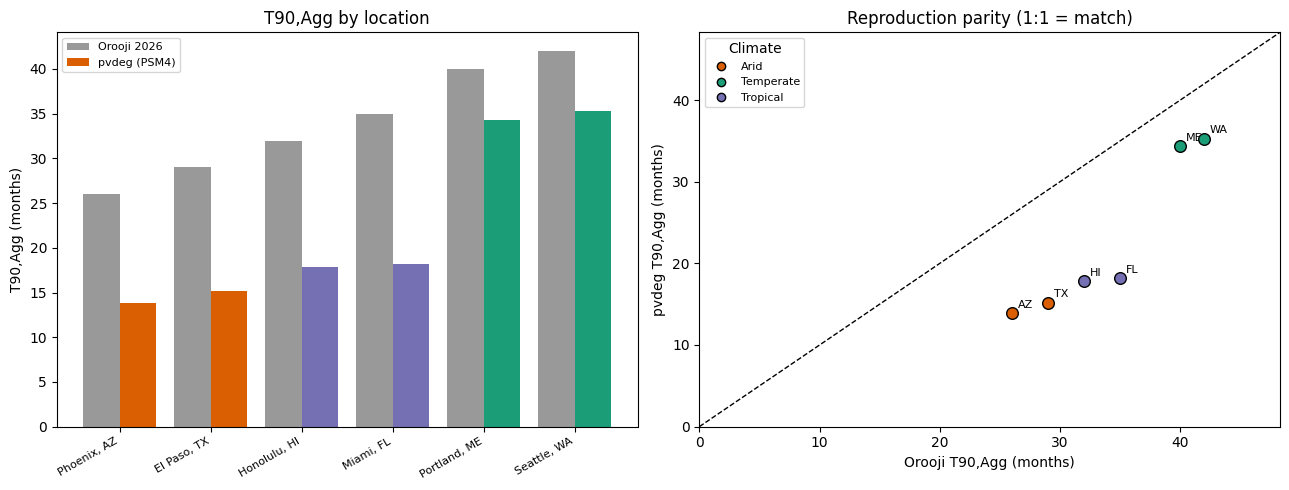

In [11]:
# Publication comparison: plots + 12-month table
if df_map.empty:
    print("df_map is empty - run the US-map fetch cell first.")
else:
    # T90,Agg by location
    # PSM4 is used for the 6-location view)
    cmp = df_map.copy()
    cmp["orooji_T90"] = cmp["state"].map(OROOJI_T90)
    cmp["climate"] = cmp["state"].map(CLIMATE)
    cmp = cmp.dropna(subset=["T_months", "orooji_T90"]).sort_values("orooji_T90")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    xpos, w = np.arange(len(cmp)), 0.4
    ax1.bar(xpos - w / 2, cmp["orooji_T90"], w, label="Orooji 2026", color="0.6")
    ax1.bar(
        xpos + w / 2,
        cmp["T_months"],
        w,
        label="pvdeg (PSM4)",
        color=[_ccolor[c] for c in cmp["climate"]],
    )
    ax1.set_xticks(xpos)
    ax1.set_xticklabels(cmp["location"], rotation=30, ha="right", fontsize=8)
    ax1.set_ylabel(f"{T_LABEL},Agg (months)")
    ax1.set_title(f"{T_LABEL},Agg by location")
    ax1.legend(fontsize=8)

    lim = max(cmp["orooji_T90"].max(), cmp["T_months"].max()) * 1.15
    ax2.plot([0, lim], [0, lim], "k--", lw=1, label="1:1")
    for _, r in cmp.iterrows():
        ax2.scatter(
            r["orooji_T90"],
            r["T_months"],
            s=70,
            color=_ccolor[r["climate"]],
            edgecolor="k",
            zorder=3,
        )
        ax2.annotate(
            r["state"],
            (r["orooji_T90"], r["T_months"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )
    ax2.set_xlim(0, lim)
    ax2.set_ylim(0, lim)
    ax2.set_xlabel(f"Orooji {T_LABEL},Agg (months)")
    ax2.set_ylabel(f"pvdeg {T_LABEL},Agg (months)")
    ax2.set_title("Reproduction parity (1:1 = match)")
    ax2.legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="o",
                ls="",
                color=c,
                label=k.title(),
                markeredgecolor="k",
            )
            for k, c in _ccolor.items()
        ],
        fontsize=8,
        title="Climate",
    )
    fig.tight_layout()

    # CE & PR_Agg at 12 months - only the two sites Orooji plots in Fig 4 (AZ, WA).
    rows = []
    for st in OROOJI_FIG4:
        rows.append(
            {
                "loc": st,
                "CE_PSM4": round(_at_one_year(ce_series[st]), 3),
                "CE_PVGIS": round(_at_one_year(pvgis_ce[st]), 3),
                "CE_Orooji": OROOJI_FIG4[st][0],
                "PRagg_PSM4": round(_at_one_year(pr_series[st]), 3),
                "PRagg_PVGIS": round(_at_one_year(pvgis_pr[st]), 3),
                "PRagg_Orooji": OROOJI_FIG4[st][1],
            }
        )
    print("CE & PR_Agg at 12 months  (PSM4 / PVGIS / Orooji Fig 4):")
    print(pd.DataFrame(rows).to_string(index=False))